In [1]:
import numpy as np
import meshtools as mt
import matplotlib.pyplot as plt

In [2]:
LENGTH = 0.01
length = 0.01

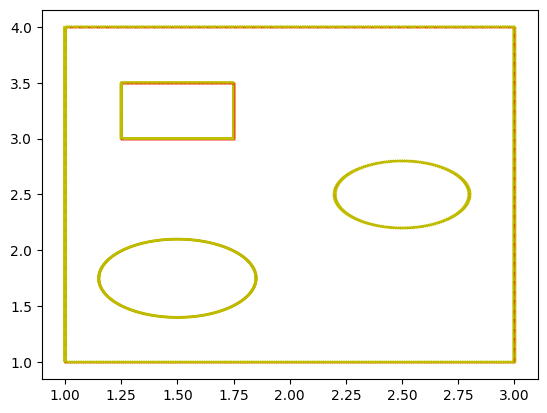

In [ ]:
knots1, elements1 = mt.RectangleSegments([1,1], [3,4], edge_length=LENGTH)
knots2, elements2 = mt.RectangleSegments([1.25, 3], [1.75, 3.5], edge_length=LENGTH/5)
knots3, elements3 = mt.CircleSegments([1.5, 1.75], radius=0.35, edge_length=LENGTH/5)
knots4, elements4 = mt.CircleSegments([2.5, 2.5,], radius=0.3, edge_length=LENGTH)

knots, elements, indizies = mt.AddMultipleCurves(knots1, elements1, knots2, elements2, knots3, elements3, knots4, elements4)


mt.PlotBoundary(knots,elements,'Segments')
plt.show()

poi,tri,BouE,li_BE,bou_elem,CuE,li_CE=mt.DoTriMesh(knots,elements,edge_length=length, holes=[(2.5, 2.5)])

In [ ]:
np.savetxt("knots.txt", poi, fmt="%10.10f")
np.savetxt("elements.txt", tri, fmt="%10.0f")

In [ ]:
import functions as myfunc

In [ ]:
DOMAIN_KNOTS = np.loadtxt("knots.txt")
ELEMENTS = np.loadtxt("elements.txt", dtype=int) # ! dtype is important here.

def alpha1(x, y):
    if 1.25 <= x <= 1.75 and 3 <= y <= 3.5:
        return 0.01
    else:
        return 5 * y * np.power(x, 2)
    
def alpha2(x, y):
    return np.power(y, 2)

def beta(x, y):
    left_hand_side = np.power((x-1.5),2) + np.power((y-1.75), 2) 
    if left_hand_side <= 0.35**2:
        return 500
    else:
        return 5
    
def rhs(x, y):
    if x >= 2:
        return -10 * x * y
    else:
        return 0
    
# Dirichlet Boundary Conditions
DIRICHLET_INDICES = np.loadtxt("Lösung/Netz2D_dr_b).dat", dtype=int)
def dirichlet(x, y):
    return np.power(x, 2) - np.power(y, 2) + 1

# Robin Boundary Conditions
ROBIN_INDICES = np.loadtxt("Lösung/Netz2D_rr_b).dat", dtype=int)
def robin_gamma(x, y):
    return 3 * x * y

def robin_rhs(x, y):
    return 20

In [ ]:
stiffness_matrix, load_vector = myfunc.assemble_global_system(DOMAIN_KNOTS, ELEMENTS, alpha1, alpha2, beta, rhs)
stiffness_matrix, load_vector = myfunc.insert_robin_values(DOMAIN_KNOTS, stiffness_matrix, load_vector, ROBIN_INDICES, robin_gamma, robin_rhs)
stiffness_matrix, load_vector = myfunc.insert_dirichlet_values(DOMAIN_KNOTS, stiffness_matrix, load_vector, DIRICHLET_INDICES, dirichlet)

solution = myfunc.solve_system(DOMAIN_KNOTS, stiffness_matrix, load_vector)

KeyboardInterrupt: 

In [ ]:
myfunc.plot_result(ELEMENTS, solution, levels=50)